# **COMP 2211 Introduction to Artificial Intelligence** #
## Lab 6 - Multilayer Perceptron ##

![mlp.png](https://images.prismic.io/turing/659d78a0531ac2845a2742df_need_deep_neural_networks_5_11zon_54d2f93a48.webp?auto=format,compress)

"Konnichiwa!" 🌸

Have you ever stared at your computer screen, feeling helpless when doing a certain Lab or PA that's due this week? Well... how about taking a rest and watching an episode of anime! (Please refrain from actually doing so in this lab or else we would be disappointed at you :(
    
As a true connoisseur of both anime and literature, I know that numbers aren't everything. **The plot matters!** Is it another generic isekai where the protagonist gets hit by a truck? Or is it an original masterpiece with deep life lessons? The answer lies in the **Synopsis**.

In this lab, you will build a **Multilayer Perceptron** that reads the anime's plot summary (`Synopsis`) *and* analyzes its metadata to predict its performance (`Score`).

Let's teach a machine to *rate* animes!

## **Lab Tasks Overview**

1. **Loading & Preprocessing:** Import the anime dataset and handle missing text. Standardize numerical stats and encode categorical features.
2. **Text Vectorization:** Convert raw plot summaries into numerical sequences.
3. **Model Building:** Build a multi-input model using the Keras Functional API.
4. **Compilation & Training:** Compile and train the model to find patterns.
5. **Evaluation & Visualization:** Evaluate its accuracy (R² Score).
<br>

We will focus on the `Synopsis` mainly, and other features such as `Source`, `Popularity`, `Members`, `Favorites`, `Studios`, `Genres`, and `Themes` to predict the `Score`, from the *Anime Dataset 2025*:

* **Synopsis:** A brief summary of the anime's plot. (Our primary NLP input).
* **Source:** The original material the anime is based on (e.g., Manga, Light Novel, Original).
* **Popularity:** Popularity rank based on user interactions (e.g., views, follows).
* **Members:** The number of users who have added the anime to their list.
* **Favorites:** The number of users who have marked the anime as a favorite.
* **Studios:** The production studio(s) responsible for creating the anime.
* **Genres:** The primary genres of the anime (e.g., Action, Comedy, Sci-Fi).
* **Themes:** The thematic elements of the anime (e.g., Space, Detective, Adult Cast).

In [40]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

if __name__ == "__main__":
    # Load the dataset
    df = pd.read_csv('anime-dataset-2025.csv')

    # Drop rows where synopsis or score is missing
    df = df.dropna(subset=['Synopsis', 'Score'])

    print(f"{len(df)} anime records loaded.")
    # print(df.head())
    # df.info()

14026 anime records loaded.


In [41]:
if __name__ == "__main__":
    # Just out of personal curiosity, I'd like to see some of the most popular animes in recent years ;)
    # You could see some familiar names in here if you're also an anime fan
    df[df['Aired From'] > "2023-01-01"].sort_values('Rank').head()

### **Task 1: Loading & Preprocessing**

Before our model can begin training, we need to load and clean the dataset. We will focus on the **Synopsis** (text feature) and several other numerical and categorical features.

**The Feature Set:**

* **Synopsis:** A brief summary of the plot (Primary NLP input).
* **Metadata:** `Source`, `Popularity`, `Members`, `Favorites`, `Studios`, `Genres`, and `Themes`.

**Your job:**

1. Load the dataset. (done for you)
2. Drop rows where `Synopsis` and/or `Score` are missing. (done for you)
3. Split the data into Training (80%) and Testing (20%) sets.
4. Apply `StandardScaler` to numerical features and `OneHotEncoder` to categorical features.

In [42]:
def preprocess(df):
    global preprocessor

    # TODO: Define features
    # Synopsis is just a fancy word for sentence, so we will treat it as a text feature.The rest of the features either numerical or categorical.

    text_col = 'Synopsis'
    num_cols = ['Popularity', 'Members', 'Favorites']
    cat_cols = ['Source', 'Studios', 'Genres', 'Themes']

    # TODO: Split data with train_test_split()
    # hint: note we should have two groups of X_train and X_test datasets—one for the text feature and the other for the rest
    X_text = df[text_col]
    X_non_text = df[num_cols + cat_cols]
    y = df['Score']

    X_text_train, X_text_test, X_train, X_test, y_train, y_test = train_test_split(
       X_text, X_non_text, y, test_size=0.2, random_state=42
    )

    # TODO: Preprocess features
    # hint: Pass in `handle_unknown='ignore', sparse_output=False` into OneHotEncoder()
    preprocessor = ColumnTransformer([
        ('num', Pipeline([
            ('log', FunctionTransformer(lambda x: np.log10(x + 1))), # To ensure the minimum value is 1
            ('scaler', StandardScaler())
        ]), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ])

    X_text_train = X_text_train.values
    X_text_test = X_text_test.values
    X_train = preprocessor.fit_transform(X_train)
    X_test = preprocessor.transform(X_test)

    # return all datasets
    return X_text_train, X_text_test, X_train, X_test, y_train, y_test

if __name__ == "__main__":
    X_text_train, X_text_test, X_train, X_test, y_train, y_test = preprocess(df)
    print("dataset shapes:")
    for dataset in [X_text_train, X_text_test, X_train, X_test, y_train, y_test]:
        print(dataset.shape)

dataset shapes:
(11220,)
(2806,)
(11220, 2858)
(2806, 2858)
(11220,)
(2806,)


**Expected output:**

In [43]:
# dataset shapes:
# (11220,)
# (2806,)
# (11220, 2858)
# (2806, 2858)
# (11220,)
# (2806,)



### **Task 2: Text Vectorization**

Machines don't understand words; they understand vectors. We need to map every word in our synopses to a unique vector.

**Your job:**

1. Initialize a `TextVectorization` layer with a 50,000 vocabulary size.
2. `adapt` the layer to your training text to create vector mappings of the top 50,000 words.

In [44]:
if __name__ == "__main__":
    # Statistics on the number of words in the synopses
    df['Synopsis'].str.split().apply(lambda x: len(x)).describe()

In [45]:
if __name__ == "__main__":
    # The number of unique words in the synopses
    import itertools
    unique_words = set(itertools.chain.from_iterable(df['Synopsis'].str.split()))
    # print(len(unique_words))
   

In [46]:
# TODO
from tensorflow.keras.layers import TextVectorization

# Feel free to adjust these two parameters
MAX_VOCAB = 20000
SEQ_LEN = 400

# TODO: initialize and adapt the vectorizer to the correct dataset
def vectorize(X, MAX_VOCAB = MAX_VOCAB, SEQ_LEN = SEQ_LEN):
    global vectorizer
    # 1. Initialize TextVectorization layer
    vectorizer = TextVectorization(
        max_tokens=MAX_VOCAB,       
        output_mode='int',          # words into integers
        output_sequence_length=SEQ_LEN   
    )
    
    # 2. Adapt (learn vocabulary) from TRAINING text
    vectorizer.adapt(X)
    return vectorizer(X)


if __name__ == "__main__":
    vectorize(X_text_train)

    # print('train: ',X_text_train)
    # print('train size: ',X_text_train.shape)
    # print(b)
    # print('vectorized train size: ',b.shape)
    

### **Task 3: Model Building**

This is the main part of the lab. We will use the **Keras Functional API** to build a model with two input branches that merge into one centralized decision-making branch at the end.

**Why GlobalMaxPool1D?**

It "expands" the sequence of word vectors into a single "combined vector" that captures the overall theme of the plot, making it compatible with our other 1D features.

**Your job:**

1. Create the **Text Branch** (Input -> Vectorizer -> Embedding -> GlobalMaxPool1D).
2. Create the **Metadata Branch** (Input -> Dense layer).
3. `Concatenate` both branches and add final layers to output a single predicted score.

**(Your model's size (total parameters) should not exceed 10M; for your reference, the solution model's size is around 5-6M, but it does not mean you'll need this many to get full marks)**

In [47]:
# TODO
def build_model():
    # Branch 1: The Synopsis (Text)
    text_input = layers.Input(shape=(1,), dtype=tf.string, name='text_input')
    # 文字 → 数字序列
    x = vectorizer(text_input)
    
    # 词嵌入（把数字变成有意义的向量）
    x = layers.Embedding(
        input_dim=len(vectorizer.get_vocabulary()),  # dict size
        output_dim=64,                              # vector dimension
        name='embedding'
    )(x)
    
    # 压缩成一个向量（
    x = layers.GlobalMaxPool1D(name='global_max_pool')(x)


    # Branch 2: The other features (Metadata)
    metadata_input = layers.Input(shape=(X_train.shape[1],), name='metadata_input') # Fill in the correct shape

    meta = layers.Dense(128, activation='relu')(metadata_input)
    meta = layers.Dropout(0.3)(meta)
    meta = layers.Dense(64, activation='relu')(meta)


    # Merge the two branches
    combined = layers.concatenate([x, meta])
    y = layers.Dense(32, activation='relu')(combined)
    y = layers.Dense(1, activation=None, name='output')(y)  # 预测分数 → 线性输出
    output = y

    return models.Model(inputs=[text_input, metadata_input], outputs=output)

if __name__ == "__main__":
    model = build_model()
    model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ metadata_input      │ (None, 2858)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization… │ (None, 400)       │          0 │ text_input[0][0]  │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 128)       │    365,952 │ metadata_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 400, 64)   │  1,280,000 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pool     │ (None, 64)        │          0 │ embedding[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 64)        │      8,256 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 128)       │          0 │ global_max_pool[… │
│ (Concatenate)       │                   │            │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 32)        │      4,128 │ concatenate_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         33 │ dense_14[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,658,369 (6.33 MB)

 Trainable params: 1,658,369 (6.33 MB)

 Non-trainable params: 0 (0.00 B)

### **Task 4: Task 4: Compilation & Training**

(Trust me, the most difficult tasks are over, you are almost there :)

**Your job:** Compile the model with the `adam` optimizer and `mse` loss. Train the model while monitoring Mean Absolute Error (`mae`) to see how many points off our predictions are from the true scores.

In [48]:
if __name__ == "__main__":
    # TODO: compile the model
    model.compile(
        optimizer = "adam",
        loss = "mse",
        metrics = ["mae"]
    )

    # Feel free to adjust the training parameters
    # hint: Remember to pass in both `X_text_train` and `X_train`
    history = model.fit(
        [X_text_train, X_train], y_train,
        validation_split=0.2,
        epochs=5,
        batch_size=64
    )

    model.save('anime_model.keras')

Epoch 1/5
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 4.2364 - mae: 1.2106 - val_loss: 0.3807 - val_mae: 0.4636
Epoch 2/5
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.2965 - mae: 0.4125 - val_loss: 0.3055 - val_mae: 0.4067
Epoch 3/5
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.2331 - mae: 0.3618 - val_loss: 0.2895 - val_mae: 0.3902
Epoch 4/5
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.1947 - mae: 0.3254 - val_loss: 0.2849 - val_mae: 0.3859
Epoch 5/5
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.1658 - mae: 0.2976 - val_loss: 0.2769 - val_mae: 0.3781


### **Task 5: Evaluation & Visualization** (Ungraded)

**Your job:** Use the test set to see how well the model predicts anime scores by calculating the **R² Score** (the closer to 1.0, the better). Then feed a raw synopsis into the model and see what score is outputted.

88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test R² Score: 0.70


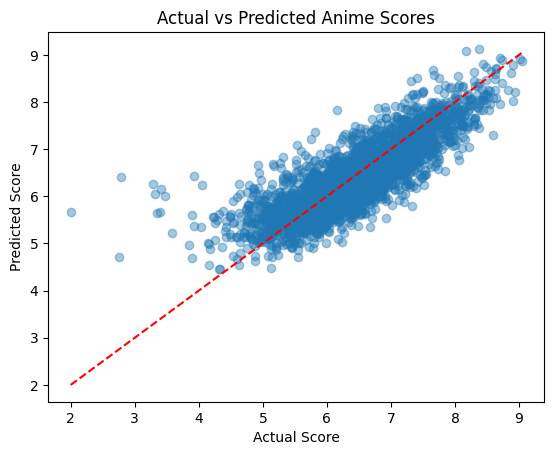

In [49]:
if __name__ == "__main__":
    # Predict
    y_pred = model.predict([X_text_test, X_test])

    # Evaluate
    score = r2_score(y_test, y_pred)
    print(f"Test R² Score: {score:.2f}")

    # Visualize
    plt.scatter(y_test, y_pred, alpha=0.4)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
    plt.title('Actual vs Predicted Anime Scores')
    plt.xlabel('Actual Score')
    plt.ylabel('Predicted Score')
plt.show()

## **Grading Scheme (10 points total)**

* **2 pts — Data Preprocessing:** Correctly splitting data (80/20) and implementing a `ColumnTransformer` to scale numerical data and encode categorical features.
* **1 pts — Text Vectorization:** Correctly initializing the `TextVectorization` layer and **adapting** it to the correct training set.
* **3 pts — Functional API Architecture:** Successful implementation of the two-branch model. This includes the text branch, the metadata branch, and the `Concatenate` branch of the two.
* **1 pts — Model Compilation & Training:** Proper selection of loss function, optimizer, and metrics.


#### **3 pts — Model Accuracy:** Points awarded based on the final r2 score on the hidden test set.

* **3 pts:**  (>=0.61)
* **2 pts:**  (>=0.58)
* **1 pts:**  (>=0.55)


**Submission:**

1. Download the notebook as a python (`.py`) script.
2. Export your trained model as `anime_model.keras`.
3. Zip these two files together and submit them on **Zinc**.

Hope you had fun fellow anime enjoyers! May you find your 10/10 masterpieces! 🌸✨